# X-ray cross-match

Cross-match the OVRO-LWA metacatalog against X-ray catalogs.
This notebook mirrors the structure of `radio_crossmatch.ipynb` and implements
**eRASS:3 Main** (+ Legacy Survey DR10 counterparts) plus optional ROSAT
sections for **2RXS** compact sources, **Freund et al. 2022** stellar
counterparts, and **Xu et al. 2022** RXGCC galaxy clusters.

| Catalog | Band | Role |
| --- | --- | --- |
| [eRASS:3 Main](https://erosita.mpe.mpg.de/) | X-ray (0.2–2.3 keV) | Classification / X-ray association |
| [2RXS (Boller+2016)](https://doi.org/10.1051/0004-6361/201525648) | ROSAT 0.1–2.4 keV | Compact / point-like sources |
| [Freund+2022 ROSAT stars](https://doi.org/10.1051/0004-6361/202142573) | ROSAT 0.1–2.4 keV × Gaia | Stellar coronal counterparts |
| [Xu+2022 RXGCC clusters](https://doi.org/10.1051/0004-6361/202140908) | ROSAT extended | Galaxy groups / clusters |

**Footprint:** eRASS:3 Main is the German / western **Galactic** hemisphere
(`180° ≤ l < 360°`). That is **not** the same as equatorial `180 < RA < 360`.
LWA sources outside that half are not cross-matched
(`in_erass_footprint=False`, `n_erass3=0`).

**Matching:** configurable radius per side (LWA + eRASS `POS_ERR`), then
pairwise `sep ≤ max(radius_lwa, radius_ref)` via `associate_catalogs`.

**Output:** optional sidecar `metacatalog_xray.parquet` under `CATALOG_DIR`
with `eRASS3_*` classification columns on existing LWA rows (row count
unchanged). 2RXS, Freund+2022, and Xu+2022 RXGCC are display / match QA only
(not written into the x-ray parquet). This notebook does **not** write or
modify `metacatalog_spectral.parquet` — X-ray fluxes are not SED / radio
spectral bands.

**Sky QA:** Radio-button **Image survey** HiPS (`eRASS3` / `LWA`), LWA HiPS
dropdown when LWA is selected, and **Overlay catalogs** toggle buttons for
LWA + eRASS:3 beam markers (same pattern as `radio_crossmatch.ipynb`).

**Cached mode:** `USE_CACHED_CROSSMATCH = True` skips load/match/attach/write
and reads the x-ray parquet for Visual QA.

**Run cells in order.** Reload from disk / restart the kernel after API changes.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lwa_catalog import CatalogLayout, read_metacatalog
from lwa_catalog.io import write_table
from lwa_catalog.analyze import (
    CrossmatchRadiusSpec,
    ERASS3_REFERENCE_RADIUS_LOCALIZATION,
    FREUND2022_REFERENCE_RADIUS_LOCALIZATION,
    LWA_CROSSMATCH_RADIUS_LOCALIZATION,
    RXGCC_REFERENCE_RADIUS_BEAM,
    TWORXS_REFERENCE_RADIUS_LOCALIZATION,
    Erass3MatchConfig,
    Freund2022MatchConfig,
    TworxsMatchConfig,
    Xu2022MatchConfig,
    attach_erass3_to_metacatalog,
    class_gal_exgal_counts,
    describe_crossmatch_radius,
    load_erass3_catalog,
    load_freund2022_catalog,
    load_tworxs_catalog,
    load_xu2022_catalog,
    match_catalog_to_erass3,
    match_catalog_to_freund2022,
    match_catalog_to_tworxs,
    match_catalog_to_xu2022,
    summarize_erass3_match,
    summarize_freund2022_match,
    summarize_tworxs_match,
    summarize_xu2022_match,
    CORE_CLEAN_EXCLUDE_FLAGS,
    CORE_CLEAN_EXCLUDE_MASK,
)
from lwa_catalog.constants import (
    ERASS3_DEFAULT_PATH,
    ERASS3_GLON_MAX_DEG,
    ERASS3_GLON_MIN_DEG,
    ERASS3_POSITION_ERROR_DEFAULT_ARCSEC,
    FREUND2022_DEFAULT_PATH,
    FREUND2022_DEFAULT_PIJ_MIN,
    FREUND2022_DEFAULT_PSTELLAR_MIN,
    FREUND2022_POSITION_ERROR_DEFAULT_ARCSEC,
    RXGCC_DEFAULT_EXTENT_ARCMIN,
    RXGCC_DEFAULT_PATH,
    TWORXS_DEFAULT_EXIML_MIN,
    TWORXS_DEFAULT_PATH,
    TWORXS_POSITION_ERROR_DEFAULT_ARCSEC,
)

# --- operator config ---
CATALOG_DIR = Path("/fast/claw/metacatalog_healpix_IdTR-0.75s_subband/")
ERASS3_PATH = ERASS3_DEFAULT_PATH
FREUND2022_PATH = FREUND2022_DEFAULT_PATH
XU2022_PATH = RXGCC_DEFAULT_PATH  # FITS table despite .dat suffix
TWORXS_PATH = TWORXS_DEFAULT_PATH  # CDS ASCII; .dat.gz on disk (plain .dat also OK)
# Same default exclusion set as metacatalog_reliability.ipynb (HiPS core_clean).
QUALITY_EXCLUDE_FLAGS = list(CORE_CLEAN_EXCLUDE_FLAGS)
QUALITY_FLAG_MASK = CORE_CLEAN_EXCLUDE_MASK
WRITE_CROSSMATCH = True
USE_CACHED_CROSSMATCH = False  # True: skip load/match/attach/write; Visual QA reads parquet
RUN_FREUND2022_CROSSMATCH = True  # independent of USE_CACHED_CROSSMATCH
RUN_XU2022_CROSSMATCH = True  # independent of USE_CACHED_CROSSMATCH
RUN_TWORXS_CROSSMATCH = True  # independent of USE_CACHED_CROSSMATCH

# --- cross-match radius ---
LWA_MATCH_RADIUS = CrossmatchRadiusSpec(mode="localization", sigma_scale=3.0)
# eRASS:3 POS_ERR is 1σ radial (arcsec); localization uses E_RA/E_DEC derived on load.
ERASS3_REFERENCE_RADIUS = CrossmatchRadiusSpec(
    mode="localization",
    sigma_scale=5.0,
    default_arcsec=ERASS3_POSITION_ERROR_DEFAULT_ARCSEC,
)
# Freund+2022 ePos is 1σ radial RASS uncertainty (arcsec); same localization path.
FREUND2022_REFERENCE_RADIUS = CrossmatchRadiusSpec(
    mode="localization",
    sigma_scale=5.0,
    default_arcsec=FREUND2022_POSITION_ERROR_DEFAULT_ARCSEC,
)
# Xu+2022 RXGCC: per-cluster BMAJ from R500* (arcmin); beam mode on reference side.
XU2022_REFERENCE_RADIUS = CrossmatchRadiusSpec(
    mode="beam",
    default_arcsec=RXGCC_DEFAULT_EXTENT_ARCMIN * 60.0,
)
# 2RXS: POS_ERR from 45″×hypot(XERR,YERR); localization on reference side.
TWORXS_REFERENCE_RADIUS = CrossmatchRadiusSpec(
    mode="localization",
    sigma_scale=5.0,
    default_arcsec=TWORXS_POSITION_ERROR_DEFAULT_ARCSEC,
)

layout = CatalogLayout(CATALOG_DIR)
# Fusion metacatalog to read. None → CATALOG_DIR/metacatalog.parquet.
# Example provisional: layout.root / "metacatalog_test.parquet"
METACATALOG_PATH: Path | None = None
INPUT_PATH = METACATALOG_PATH if METACATALOG_PATH is not None else layout.metacatalog()
CROSSMATCH_OUTPUT = layout.metacatalog_xray()
erass3_config = Erass3MatchConfig(
    catalog_path=ERASS3_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=ERASS3_REFERENCE_RADIUS,
)
freund2022_config = Freund2022MatchConfig(
    catalog_path=FREUND2022_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=FREUND2022_REFERENCE_RADIUS,
    pstellar_min=FREUND2022_DEFAULT_PSTELLAR_MIN,
    pij_min=FREUND2022_DEFAULT_PIJ_MIN,
    exclude_subdwarf=True,
)
xu2022_config = Xu2022MatchConfig(
    catalog_path=XU2022_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=XU2022_REFERENCE_RADIUS,
    classes=None,  # e.g. ("G", "S") to drop Bronze
)
tworxs_config = TworxsMatchConfig(
    catalog_path=TWORXS_PATH,
    target="metacatalog",
    lwa_radius=LWA_MATCH_RADIUS,
    reference_radius=TWORXS_REFERENCE_RADIUS,
    eximl_min=TWORXS_DEFAULT_EXIML_MIN,  # None = full catalog (~30% spurious)
)

print("CATALOG_DIR =", layout.root.resolve())
print("INPUT_PATH =", INPUT_PATH.resolve())
print("INPUT_PATH exists:", INPUT_PATH.is_file())
print("ERASS3_PATH =", Path(ERASS3_PATH).resolve())
print("FREUND2022_PATH =", Path(FREUND2022_PATH).resolve())
print("XU2022_PATH =", Path(XU2022_PATH).resolve())
print("TWORXS_PATH =", Path(TWORXS_PATH).resolve())
print(
    f"eRASS:3 footprint: {ERASS3_GLON_MIN_DEG:g}° ≤ Gal l < {ERASS3_GLON_MAX_DEG:g}°"
)
print("QUALITY_EXCLUDE_FLAGS =", QUALITY_EXCLUDE_FLAGS)
print("QUALITY_FLAG_MASK =", QUALITY_FLAG_MASK)
print("WRITE_CROSSMATCH =", WRITE_CROSSMATCH)
print("USE_CACHED_CROSSMATCH =", USE_CACHED_CROSSMATCH)
print("RUN_FREUND2022_CROSSMATCH =", RUN_FREUND2022_CROSSMATCH)
print("RUN_XU2022_CROSSMATCH =", RUN_XU2022_CROSSMATCH)
print("RUN_TWORXS_CROSSMATCH =", RUN_TWORXS_CROSSMATCH)
print(
    "xray product exists:" if CROSSMATCH_OUTPUT.is_file() else "xray product MISSING:",
    CROSSMATCH_OUTPUT.resolve(),
)
print("NOTE: does not write metacatalog_spectral.parquet")
print("CROSSMATCH_OUTPUT =", CROSSMATCH_OUTPUT.resolve())
print("LWA match radius:", describe_crossmatch_radius(LWA_MATCH_RADIUS))
print("eRASS:3 reference radius:", describe_crossmatch_radius(ERASS3_REFERENCE_RADIUS))
print(
    "Freund+2022 reference radius:",
    describe_crossmatch_radius(FREUND2022_REFERENCE_RADIUS),
)
print(
    "Freund+2022 science cut:"
    f" pstellar>{freund2022_config.pstellar_min},"
    f" pij>{freund2022_config.pij_min},"
    f" exclude_subdwarf={freund2022_config.exclude_subdwarf}"
)
print(
    "Xu+2022 / RXGCC reference radius:",
    describe_crossmatch_radius(XU2022_REFERENCE_RADIUS),
)
print("Xu+2022 Class filter =", xu2022_config.classes)
print(
    "2RXS reference radius:",
    describe_crossmatch_radius(TWORXS_REFERENCE_RADIUS),
)
print("2RXS ExiML min =", tworxs_config.eximl_min)

if USE_CACHED_CROSSMATCH:
    print(
        "USE_CACHED_CROSSMATCH=True → skip metacatalog load, eRASS:3 match, "
        "attach, and write. Jump to Visual QA (or Run All; those cells no-op)."
    )
else:
    print("USE_CACHED_CROSSMATCH=False → full eRASS:3 cross-match will run.")


## Load metacatalog

Reads `metacatalog.parquet` (expects `quality_flag` from
`metacatalog_reliability.ipynb`), applies `QUALITY_FLAG_MASK`, and keeps that
subset for matching. Does **not** prefer the radio spectral product by default
(`prefer_spectral=False`).

Skipped when `USE_CACHED_CROSSMATCH=True`.


In [ ]:
if USE_CACHED_CROSSMATCH:
    print("Skipping metacatalog load (USE_CACHED_CROSSMATCH=True)")
else:
    metacatalog = read_metacatalog(
        INPUT_PATH,
        quality_mask=QUALITY_FLAG_MASK,
    )
    print(f"loaded from: {INPUT_PATH}")
    print(f"metacatalog rows after quality mask: {len(metacatalog):,}")
    print(f"columns: {len(metacatalog.columns)}")


In [3]:
def match_offsets_arcsec(
    meta_flags: pd.DataFrame,
    ref_footprint: pd.DataFrame,
    *,
    positions_col: str,
    match_frame: pd.DataFrame | None = None,
    closest_only: bool = True,
) -> np.ndarray:
    """Sky separations (arcsec) for meta↔survey matches."""
    from astropy.coordinates import SkyCoord
    import astropy.units as u

    if meta_flags.empty or ref_footprint.empty:
        return np.asarray([], dtype=float)

    if match_frame is not None:
        if len(match_frame) != len(meta_flags):
            raise ValueError(
                f"match_frame length {len(match_frame)} != meta_flags "
                f"length {len(meta_flags)}"
            )
        meta_ra = pd.to_numeric(match_frame["RA"], errors="coerce").to_numpy(dtype=float)
        meta_dec = pd.to_numeric(match_frame["DEC"], errors="coerce").to_numpy(dtype=float)
    else:
        meta_ra = pd.to_numeric(meta_flags["RA"], errors="coerce").to_numpy(dtype=float)
        meta_dec = pd.to_numeric(meta_flags["DEC"], errors="coerce").to_numpy(dtype=float)

    ref_ra = pd.to_numeric(ref_footprint["RA"], errors="coerce").to_numpy(dtype=float)
    ref_dec = pd.to_numeric(ref_footprint["DEC"], errors="coerce").to_numpy(dtype=float)
    seps: list[float] = []
    for i, (_, flag) in enumerate(meta_flags.iterrows()):
        positions = flag.get(positions_col, [])
        if positions is None or not hasattr(positions, "__len__") or len(positions) == 0:
            continue
        if not (np.isfinite(meta_ra[i]) and np.isfinite(meta_dec[i])):
            continue
        meta_sc = SkyCoord(ra=meta_ra[i] * u.deg, dec=meta_dec[i] * u.deg)
        pair_seps: list[float] = []
        for pos in positions:
            j = int(pos)
            if j < 0 or j >= len(ref_ra):
                continue
            if not (np.isfinite(ref_ra[j]) and np.isfinite(ref_dec[j])):
                continue
            ref_sc = SkyCoord(ra=ref_ra[j] * u.deg, dec=ref_dec[j] * u.deg)
            pair_seps.append(float(meta_sc.separation(ref_sc).arcsec))
        if not pair_seps:
            continue
        if closest_only:
            seps.append(min(pair_seps))
        else:
            seps.extend(pair_seps)
    return np.asarray(seps, dtype=float)


def plot_match_offset_hist(
    all_seps_arcsec: np.ndarray,
    matched_seps_arcsec: np.ndarray | None = None,
    *,
    title: str,
    bins: int = 40,
) -> None:
    """Log-log histograms of match offsets."""
    def _positive(arr: np.ndarray) -> np.ndarray:
        out = np.asarray(arr, dtype=float)
        return out[np.isfinite(out) & (out > 0.0)]

    all_finite = _positive(all_seps_arcsec)
    matched_finite = (
        _positive(matched_seps_arcsec)
        if matched_seps_arcsec is not None
        else np.asarray([], dtype=float)
    )
    if all_finite.size == 0 and matched_finite.size == 0:
        print(f"No positive match offsets to plot for {title}.")
        return

    combined = (
        np.concatenate([all_finite, matched_finite])
        if matched_finite.size
        else all_finite
    )
    xmin = max(float(np.min(combined)), 1e-3)
    xmax = float(np.max(combined))
    if xmax <= xmin:
        xmax = xmin * 10.0
    bin_edges = np.logspace(np.log10(xmin), np.log10(xmax), int(bins) + 1)

    fig, ax = plt.subplots(figsize=(6, 4))
    if all_finite.size:
        ax.hist(
            all_finite,
            bins=bin_edges,
            histtype="stepfilled",
            alpha=0.45,
            edgecolor="k",
            color="C0",
            label=f"closest hit (n={all_finite.size:,})",
        )
    if matched_finite.size:
        ax.hist(
            matched_finite,
            bins=bin_edges,
            histtype="stepfilled",
            alpha=0.55,
            edgecolor="k",
            color="C3",
            label=f"unique 1:1 matched (n={matched_finite.size:,})",
        )

    median_src = matched_finite if matched_finite.size else all_finite
    med = float(np.median(median_src))
    ax.axvline(
        med,
        color="C1",
        ls="--",
        lw=1.2,
        label=f"matched median = {med:.2f} arcsec",
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Cross-match offset (arcsec)")
    ax.set_ylabel("Number of matches")
    ax.set_title(title)
    ax.legend(frameon=False)
    plt.show()

    def _stats(label: str, arr: np.ndarray) -> None:
        if arr.size == 0:
            print(f"{label}: n=0")
            return
        print(
            f"{label}: n={arr.size:,}  median={float(np.median(arr)):.2f} arcsec  "
            f"p90={np.percentile(arr, 90):.2f} arcsec  "
            f"p99={np.percentile(arr, 99):.2f} arcsec"
        )

    _stats("closest hit", all_finite)
    _stats("unique 1:1 matched", matched_finite)


## eRASS:3 cross-match (X-ray)

Associate quality-cleared LWA rows with [eROSITA eRASS:3 Main](https://erosita.mpe.mpg.de/)
(+ Legacy Survey DR10 counterparts). Only the classification / match columns
listed in the library (`ERASS3_LOAD_COLUMNS`) are loaded from the FITS file.

**Primary metric:** completeness — fraction of **in-footprint** LWA rows that
match ≥1 eRASS:3 source.

**Failure-mode metric:** eRASS over-splitting — one eRASS source matched by
multiple metacatalog rows.

Skipped when `USE_CACHED_CROSSMATCH=True`.


In [4]:
if USE_CACHED_CROSSMATCH:
    print("Skipping eRASS:3 cross-match (USE_CACHED_CROSSMATCH=True)")
else:
    erass3 = load_erass3_catalog(ERASS3_PATH)
    print(f"eRASS:3 rows (selected cols): {len(erass3):,}")
    print(f"RA range: {erass3['RA'].min():.2f} .. {erass3['RA'].max():.2f}")
    print(f"POS_ERR median: {float(erass3['POS_ERR'].median()):.2f} arcsec")
    erass3_result = match_catalog_to_erass3(
        metacatalog,
        erass3=erass3,
        config=erass3_config,
    )
    print(summarize_erass3_match(erass3_result))
    print(
        "class_gal_exgal value_counts (footprint catalog):\n",
        erass3_result.erass3_footprint["class_gal_exgal"]
        .value_counts(dropna=False)
        .sort_index()
        .to_string(),
    )


eRASS:3 rows (selected cols): 1,591,243
RA range: 0.00 .. 360.00
POS_ERR median: 3.87 arcsec
LWA target rows:                  167618
LWA in eRASS footprint (Gal l):    56402
eRASS:3 footprint rows:           1591072
Meta matched (>=1 eRASS:3):         3499
Match completeness (in footprint):0.062
Meta unique match (n=1):            2393
Unique match fraction:            0.042
eRASS:3 matched (>=1 meta):         8008
eRASS:3 recovery:                 0.005
eRASS:3 over-split (n_meta>1):        65
Meta multi-eRASS:3 (n>1):           1106
Max eRASS:3 hits per meta:           117

Footprint: western Galactic hemisphere (180° ≤ l < 360°).
class_gal_exgal value_counts (footprint catalog):
 class_gal_exgal
-5    175640
-1     17686
 1     11896
 2    100306
 3     74634
 4    475206
 5    735704


LWA in eRASS footprint: 56,402 / 167,618
eRASS:3 hits per in-footprint meta (value_counts):


n_erass3
0     52903
1      2393
2       378
3       224
4       135
5        72
6        60
7        39
8        37
9        32
10       24
11       25
12       11
13       16
14        8
15        3
16        8
17        1
18        4
19        2
Name: count, dtype: int64


Unmatched in-footprint meta (first 20 of 52903):


,meta_id,RA,DEC,in_erass_footprint,n_erass3,erass3_positions,matched
31,27379,184.733595,5.983629,True,0,[],False
34,14478,96.598410,-5.840229,True,0,[],False
35,16930,96.746974,-5.666091,True,0,[],False
39,34935,98.919618,-20.587347,True,0,[],False
40,147375,99.296038,-20.847574,True,0,[],False
41,38711,99.338834,-20.733172,True,0,[],False
42,145100,99.123058,-20.759079,True,0,[],False
43,144,99.152272,-20.662825,True,0,[],False
44,167,99.144789,-20.516740,True,0,[],False
52,181761,146.716356,7.517604,True,0,[],False



eRASS:3 over-split rows (first 20 of 65):


,erass3_pos,RA,DEC,DET_LIKE_0,ML_FLUX_1,n_meta,meta_ids,oversplit
42205,42205,214.900090,-19.489584,6.544791,1.921140e-14,2,"[857, 149045]",True
48600,48600,83.681709,-5.466714,6.903682,2.945655e-14,2,"[6209, 8326]",True
48601,48601,83.681709,-5.466714,6.903682,2.945655e-14,2,"[6209, 8326]",True
69798,69798,164.870975,-35.951557,6.368245,1.776232e-14,2,"[145357, 19755]",True
90664,90664,137.535508,18.536862,9.100780,3.005490e-14,2,"[2138, 145130]",True
151674,151674,36.930070,-12.837121,9.212574,1.759621e-14,2,"[5173, 148715]",True
168052,168052,175.651800,22.175848,12.300443,4.057219e-14,2,"[148751, 235]",True
191690,191690,120.584903,14.291425,6.572012,2.829219e-14,2,"[52834, 204]",True
195161,195161,186.293298,13.070163,8.923617,3.824509e-14,2,"[192, 31798]",True
195851,195851,186.293298,13.070163,8.923617,3.824509e-14,2,"[192, 31798]",True


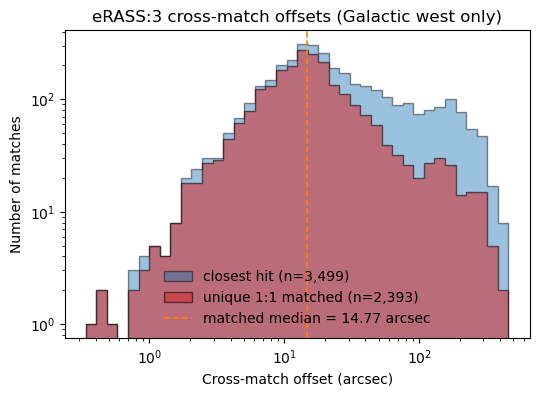

closest hit: n=3,499  median=19.01 arcsec  p90=140.30 arcsec  p99=309.88 arcsec
unique 1:1 matched: n=2,393  median=14.77 arcsec  p90=54.55 arcsec  p99=254.54 arcsec


In [5]:
if USE_CACHED_CROSSMATCH:
    print("Skipping eRASS:3 match QA tables (USE_CACHED_CROSSMATCH=True)")
else:
    erass3_meta_flags = erass3_result.meta_flags
    erass3_ref_flags = erass3_result.erass3_flags

    in_fp = erass3_meta_flags["in_erass_footprint"]
    print(
        f"LWA in eRASS footprint: {int(in_fp.sum()):,} / {len(erass3_meta_flags):,}"
    )
    print("eRASS:3 hits per in-footprint meta (value_counts):")
    display(
        erass3_meta_flags.loc[in_fp, "n_erass3"]
        .value_counts()
        .sort_index()
        .head(20)
    )

    erass3_unmatched = erass3_meta_flags.loc[in_fp & ~erass3_meta_flags["matched"]]
    print(f"\nUnmatched in-footprint meta (first 20 of {len(erass3_unmatched)}):")
    display(erass3_unmatched.head(20))

    erass3_oversplit = erass3_ref_flags.loc[erass3_ref_flags["oversplit"]]
    print(f"\neRASS:3 over-split rows (first 20 of {len(erass3_oversplit)}):")
    display(erass3_oversplit.head(20))

    erass3_fp_mask = in_fp.to_numpy()
    erass3_fp_flags = erass3_meta_flags.iloc[erass3_fp_mask]
    erass3_unique_mask = (erass3_fp_flags["n_erass3"] == 1).to_numpy()
    erass3_offsets = match_offsets_arcsec(
        erass3_fp_flags,
        erass3_result.erass3_footprint,
        positions_col="erass3_positions",
    )
    erass3_matched_offsets = match_offsets_arcsec(
        erass3_fp_flags.iloc[erass3_unique_mask],
        erass3_result.erass3_footprint,
        positions_col="erass3_positions",
    )
    plot_match_offset_hist(
        erass3_offsets,
        erass3_matched_offsets,
        title="eRASS:3 cross-match offsets (Galactic west only)",
    )


## Attach eRASS:3 columns + write

Copy selected eRASS:3 fields onto LWA rows (`eRASS3_*`, `n_erass3`,
`in_erass_footprint`, `sep_arcsec_eRASS3`). Multi-match rows keep the highest
`DET_LIKE_0` hit (sky-sep tie-break). Row count is unchanged.

Writes **`metacatalog_xray.parquet` only** when `WRITE_CROSSMATCH=True`.
Does **not** touch `metacatalog_spectral.parquet` or radio SED columns.

Skipped when `USE_CACHED_CROSSMATCH=True`.


In [6]:
if USE_CACHED_CROSSMATCH:
    print("Skipping attach/write (USE_CACHED_CROSSMATCH=True)")
else:
    xray_meta = attach_erass3_to_metacatalog(
        metacatalog,
        erass3_result.erass3_footprint,
        erass3_result.meta_flags,
    )
    assert len(xray_meta) == len(metacatalog)

    n_hit = int((xray_meta["n_erass3"] >= 1).sum())
    n_fp = int(xray_meta["in_erass_footprint"].sum())
    print(
        f"eRASS3 matched {n_hit:6d}  "
        f"in footprint {n_fp:6d}  "
        f"median sep {float(np.nanmedian(xray_meta['sep_arcsec_eRASS3'])):.2f} arcsec"
    )
    cols = [
        "meta_id",
        "RA",
        "DEC",
        "in_erass_footprint",
        "n_erass3",
        "sep_arcsec_eRASS3",
        "eRASS3_DET_LIKE_0",
        "eRASS3_ML_FLUX_1",
        "eRASS3_EXT",
        "eRASS3_class_gal_exgal",
        "eRASS3_is_blazar_in_simbad",
        "eRASS3_simbad_known_galactic",
        "eRASS3_main_id_simbad",
        "eRASS3_NWAY_p_i",
        "eRASS3_LS10_OBJID",
    ]
    display(xray_meta[[c for c in cols if c in xray_meta.columns]].head(12))

    if WRITE_CROSSMATCH:
        write_table(xray_meta, CROSSMATCH_OUTPUT, include_extras=True)
        print(f"Wrote {len(xray_meta):,} rows → {CROSSMATCH_OUTPUT.resolve()}")
    else:
        print("WRITE_CROSSMATCH=False — in-memory xray_meta only")


eRASS3 matched   3499  in footprint  56402  median sep 19.60 arcsec


,meta_id,RA,DEC,in_erass_footprint,n_erass3,sep_arcsec_eRASS3,eRASS3_DET_LIKE_0,eRASS3_ML_FLUX_1,eRASS3_EXT,eRASS3_class_gal_exgal,eRASS3_is_blazar_in_simbad,eRASS3_simbad_known_galactic,eRASS3_main_id_simbad,eRASS3_NWAY_p_i,eRASS3_LS10_OBJID
0,21,49.953594,41.499267,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
1,17,226.262570,26.013259,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
2,8,6.332600,64.157417,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
3,9,64.590484,38.041923,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
4,6,76.180447,38.110657,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
5,24,341.455013,39.674534,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
6,14,247.160718,39.550261,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
7,172571,303.768585,23.531957,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
8,18,303.648013,23.593122,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN
9,32,240.636858,1.967742,False,0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN


Wrote 167,618 rows → /fast/claw/metacatalog_healpix_IdTR-0.75s_subband/metacatalog_xray.parquet


## Classification pie (unique eRASS:3 matches)

`class_gal_exgal` for LWA rows with exactly one eRASS:3 counterpart
(`n_erass3 == 1`). Labels follow Salvato et al. (2025): negative = Galactic,
positive = extragalactic; larger absolute value ⇒ higher confidence.


Unique eRASS:3 matches (n_erass3 == 1): 2,393


,n
Galactic (moving PSF) [-5],76
Galactic (other) [-1],7
Extragalactic (1) [1],10
Extragalactic (one separator) [2],158
Extragalactic (both separators) [3],167
Extragalactic (STAREX 50–95%) [4],832
Extragalactic (STAREX ≥95%) [5],1143


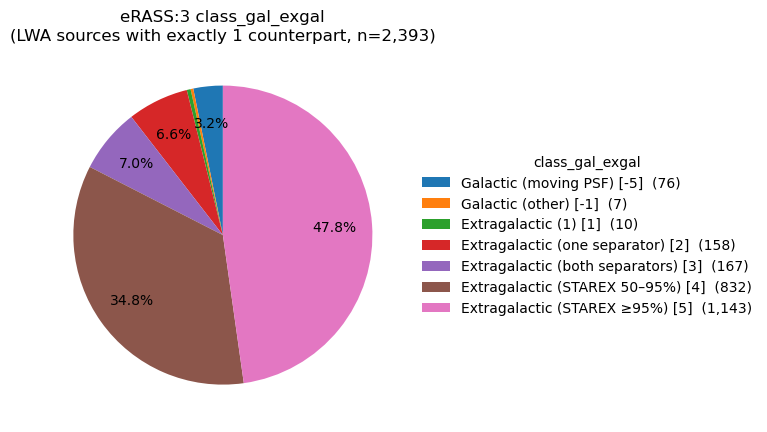

In [7]:
from lwa_catalog.io import read_table

if USE_CACHED_CROSSMATCH:
    _xray_path = layout.metacatalog_xray()
    if not _xray_path.is_file():
        print("Skipping pie chart (no metacatalog_xray.parquet)")
        counts = None
    else:
        xray_meta = read_table(_xray_path)
        counts = class_gal_exgal_counts(xray_meta, unique_only=True)
elif "xray_meta" not in globals() or not isinstance(xray_meta, pd.DataFrame):
    raise RuntimeError("Run the attach cell first (or set USE_CACHED_CROSSMATCH=True)")
else:
    counts = class_gal_exgal_counts(xray_meta, unique_only=True)

if counts is not None:
    n_unique = int((xray_meta["n_erass3"] == 1).sum()) if "n_erass3" in xray_meta.columns else 0
    print(f"Unique eRASS:3 matches (n_erass3 == 1): {n_unique:,}")
    if counts.empty:
        print("No class_gal_exgal values to plot.")
    else:
        display(counts.rename("n").to_frame())
        fig, ax = plt.subplots(figsize=(7.5, 7.5))
        wedges, _texts, _autotexts = ax.pie(
            counts.to_numpy(dtype=float),
            labels=None,
            autopct=lambda p: f"{p:.1f}%" if p >= 2.0 else "",
            startangle=90,
            pctdistance=0.75,
        )
        ax.legend(
            wedges,
            [f"{lab}  ({int(n):,})" for lab, n in counts.items()],
            title="class_gal_exgal",
            loc="center left",
            bbox_to_anchor=(1.0, 0.5),
            frameon=False,
        )
        ax.set_title(
            f"eRASS:3 class_gal_exgal\n"
            f"(LWA sources with exactly 1 counterpart, n={n_unique:,})"
        )
        plt.tight_layout()
        plt.show()


## Freund+2022 ROSAT stellar counterparts

Load [Freund et al. 2022](https://doi.org/10.1051/0004-6361/202142573)
(VizieR `J/A+A/664/A105` main catalog) from `FREUND2022_PATH` and cross-match
to the quality-filtered metacatalog with the same `associate_catalogs` +
radius-spec path used for eRASS:3.

Default science cut (paper sample): `pstellar > 0.51`, `pij > 0.5`, and
`subdwarf == False`. Match radius uses RASS `ePos` (1σ, arcsec) ×
`sigma_scale` on the reference side.

This section is **display / QA only** — it does not write
`metacatalog_xray.parquet`. Controlled by `RUN_FREUND2022_CROSSMATCH`
(independent of `USE_CACHED_CROSSMATCH`).


In [ ]:
if not RUN_FREUND2022_CROSSMATCH:
    print("Skipping Freund+2022 load (RUN_FREUND2022_CROSSMATCH=False)")
else:
    if "metacatalog" not in globals() or not isinstance(metacatalog, pd.DataFrame):
        # Cached eRASS mode skips the earlier load; pull the same quality subset.
        metacatalog = read_metacatalog(
            INPUT_PATH,
            quality_mask=QUALITY_FLAG_MASK,
        )
        print(f"loaded metacatalog for Freund+2022: {len(metacatalog):,} rows")

    freund2022 = load_freund2022_catalog(FREUND2022_PATH)
    print(f"Freund+2022 rows (all counterparts): {len(freund2022):,}")
    print(f"RA range: {freund2022['RA'].min():.2f} .. {freund2022['RA'].max():.2f}")
    print(f"DEC range: {freund2022['DEC'].min():.2f} .. {freund2022['DEC'].max():.2f}")
    print(f"ePos median: {float(freund2022['ePos'].median()):.2f} arcsec")
    print(
        "subdwarf value_counts:\n",
        freund2022["subdwarf"].value_counts(dropna=False).to_string(),
    )
    display_cols = [
        "2RXS",
        "Match",
        "ePos",
        "Sep",
        "pstellar",
        "pij",
        "RA",
        "DEC",
        "FX",
        "HR",
        "Gmag",
        "BP_RP",
        "plx",
        "subdwarf",
    ]
    print("\nSample (first 12 rows):")
    display(freund2022[[c for c in display_cols if c in freund2022.columns]].head(12))

    freund2022_result = match_catalog_to_freund2022(
        metacatalog,
        freund2022=freund2022,
        config=freund2022_config,
    )
    print(summarize_freund2022_match(freund2022_result))


In [ ]:
if not RUN_FREUND2022_CROSSMATCH:
    print("Skipping Freund+2022 match QA (RUN_FREUND2022_CROSSMATCH=False)")
else:
    freund_meta_flags = freund2022_result.meta_flags
    freund_ref_flags = freund2022_result.freund2022_flags
    freund_fp = freund2022_result.freund2022_footprint

    print("Freund+2022 hits per meta (value_counts):")
    display(freund_meta_flags["n_freund2022"].value_counts().sort_index().head(20))

    matched = freund_meta_flags.loc[freund_meta_flags["matched"]]
    print(f"\nMatched meta (first 20 of {len(matched):,}):")
    display(matched.head(20))

    # Join brightest / first unique hit columns for inspection.
    unique_mask = freund_meta_flags["n_freund2022"] == 1
    unique_meta = freund_meta_flags.loc[unique_mask].copy()
    if not unique_meta.empty and not freund_fp.empty:
        hit_pos = unique_meta["freund2022_positions"].map(lambda xs: int(xs[0]))
        hit_rows = freund_fp.iloc[hit_pos.to_numpy()].reset_index(drop=True)
        preview = unique_meta[["meta_id", "RA", "DEC", "n_freund2022"]].reset_index(
            drop=True
        )
        for col in ("2RXS", "Match", "ePos", "FX", "Gmag", "BP_RP", "plx", "pstellar", "pij"):
            if col in hit_rows.columns:
                preview[f"Freund2022_{col}"] = hit_rows[col].to_numpy()
        print(f"\nUnique 1:1 matches (first 20 of {len(preview):,}):")
        display(preview.head(20))

    oversplit = freund_ref_flags.loc[freund_ref_flags["oversplit"]]
    print(f"\nFreund+2022 over-split rows (first 20 of {len(oversplit):,}):")
    display(oversplit.head(20))

    freund_offsets = match_offsets_arcsec(
        freund_meta_flags,
        freund_fp,
        positions_col="freund2022_positions",
    )
    freund_matched_offsets = match_offsets_arcsec(
        unique_meta,
        freund_fp,
        positions_col="freund2022_positions",
    )
    plot_match_offset_hist(
        freund_offsets,
        freund_matched_offsets,
        title="Freund+2022 ROSAT stellar cross-match offsets",
    )


## Xu+2022 RXGCC ROSAT galaxy clusters

Load [Xu et al. 2022](https://doi.org/10.1051/0004-6361/202140908) RXGCC
(VizieR `J/A+A/658/A59` table3) from `XU2022_PATH` and cross-match to the
quality-filtered metacatalog.

**Note:** `/fast/claw/xu2022table3.dat` is a **FITS** table despite the
`.dat` suffix (944 clusters: Gold / Silver / Bronze).

Match radius on the cluster side uses angular `R500*` (fallback `Ext`) as
`BMAJ` via beam-mode association — i.e. LWA sources inside ~R500 of a
cluster. Optional `xu2022_config.classes` can restrict to `G` / `S` / `B`.

Display / QA only — does not write `metacatalog_xray.parquet`. Controlled by
`RUN_XU2022_CROSSMATCH` (independent of `USE_CACHED_CROSSMATCH`).


In [ ]:
if not RUN_XU2022_CROSSMATCH:
    print("Skipping Xu+2022 / RXGCC load (RUN_XU2022_CROSSMATCH=False)")
else:
    if "metacatalog" not in globals() or not isinstance(metacatalog, pd.DataFrame):
        metacatalog = read_metacatalog(
            INPUT_PATH,
            quality_mask=QUALITY_FLAG_MASK,
        )
        print(f"loaded metacatalog for Xu+2022: {len(metacatalog):,} rows")

    xu2022 = load_xu2022_catalog(XU2022_PATH)
    print(f"RXGCC rows: {len(xu2022):,}")
    print(f"RA range: {xu2022['RA'].min():.2f} .. {xu2022['RA'].max():.2f}")
    print(f"DEC range: {xu2022['DEC'].min():.2f} .. {xu2022['DEC'].max():.2f}")
    print(f"R500* median: {float(xu2022['R500_arcmin'].median()):.2f} arcmin")
    print(f"Ext median: {float(xu2022['Ext'].median()):.2f} arcmin")
    print(
        "Class value_counts:\n",
        xu2022["Class"].value_counts(dropna=False).to_string(),
    )
    display_cols = [
        "RXGCC",
        "RA",
        "DEC",
        "Ext",
        "Extml",
        "z",
        "Class",
        "Rsig",
        "R500_arcmin",
        "R500_Mpc",
        "F500",
        "L500",
        "M500",
        "TX",
        "GCXSZ",
        "GCOPT",
    ]
    print("\nSample (first 12 rows):")
    display(xu2022[[c for c in display_cols if c in xu2022.columns]].head(12))

    xu2022_result = match_catalog_to_xu2022(
        metacatalog,
        xu2022=xu2022,
        config=xu2022_config,
    )
    print(summarize_xu2022_match(xu2022_result))


In [ ]:
if not RUN_XU2022_CROSSMATCH:
    print("Skipping Xu+2022 / RXGCC match QA (RUN_XU2022_CROSSMATCH=False)")
else:
    xu_meta_flags = xu2022_result.meta_flags
    xu_ref_flags = xu2022_result.xu2022_flags
    xu_fp = xu2022_result.xu2022_footprint

    print("RXGCC hits per meta (value_counts):")
    display(xu_meta_flags["n_xu2022"].value_counts().sort_index().head(20))

    matched = xu_meta_flags.loc[xu_meta_flags["matched"]]
    print(f"\nMatched meta (first 20 of {len(matched):,}):")
    display(matched.head(20))

    unique_mask = xu_meta_flags["n_xu2022"] == 1
    unique_meta = xu_meta_flags.loc[unique_mask].copy()
    if not unique_meta.empty and not xu_fp.empty:
        hit_pos = unique_meta["xu2022_positions"].map(lambda xs: int(xs[0]))
        hit_rows = xu_fp.iloc[hit_pos.to_numpy()].reset_index(drop=True)
        preview = unique_meta[["meta_id", "RA", "DEC", "n_xu2022"]].reset_index(
            drop=True
        )
        for col in (
            "RXGCC",
            "Class",
            "z",
            "Ext",
            "R500_arcmin",
            "F500",
            "L500",
            "M500",
            "TX",
            "GCXSZ",
            "GCOPT",
        ):
            if col in hit_rows.columns:
                preview[f"RXGCC_{col}"] = hit_rows[col].to_numpy()
        print(f"\nUnique 1:1 matches (first 20 of {len(preview):,}):")
        display(preview.head(20))

    oversplit = xu_ref_flags.loc[xu_ref_flags["oversplit"]]
    print(f"\nRXGCC over-split rows (first 20 of {len(oversplit):,}):")
    display(oversplit.head(20))

    if "Class" in xu_ref_flags.columns:
        print("\nMatched RXGCC Class mix:")
        display(
            xu_ref_flags.loc[xu_ref_flags["n_meta"] > 0, "Class"]
            .value_counts(dropna=False)
            .rename("n")
            .to_frame()
        )

    xu_offsets = match_offsets_arcsec(
        xu_meta_flags,
        xu_fp,
        positions_col="xu2022_positions",
    )
    xu_matched_offsets = match_offsets_arcsec(
        unique_meta,
        xu_fp,
        positions_col="xu2022_positions",
    )
    plot_match_offset_hist(
        xu_offsets,
        xu_matched_offsets,
        title="Xu+2022 RXGCC cluster cross-match offsets",
    )


## 2RXS compact sources (Boller+2016)

Load the [second ROSAT all-sky survey source catalogue](https://doi.org/10.1051/0004-6361/201525648)
(VizieR `J/A+A/588/A103`) from `TWORXS_PATH` and cross-match to the
quality-filtered metacatalog.

**Path note:** the CDS ASCII product is large; on this machine it lives as
`/fast/claw/cat2rxs.dat.gz`. Plain `.dat` also works if you decompress it.

Default cut `ExiML >= 9` follows the paper’s cleaner sample (~5% spurious;
full catalog at 6.5 is ~30% spurious). Set `tworxs_config.eximl_min = None`
for the full table. Match radius uses `POS_ERR = 45″ × hypot(XERR, YERR)`.

Display / QA only — does not write `metacatalog_xray.parquet`. Controlled by
`RUN_TWORXS_CROSSMATCH`.


In [ ]:
if not RUN_TWORXS_CROSSMATCH:
    print("Skipping 2RXS load (RUN_TWORXS_CROSSMATCH=False)")
else:
    if "metacatalog" not in globals() or not isinstance(metacatalog, pd.DataFrame):
        metacatalog = read_metacatalog(
            INPUT_PATH,
            quality_mask=QUALITY_FLAG_MASK,
        )
        print(f"loaded metacatalog for 2RXS: {len(metacatalog):,} rows")

    print(f"Loading 2RXS from {Path(TWORXS_PATH).resolve()} …")
    tworxs = load_tworxs_catalog(TWORXS_PATH)
    print(f"2RXS rows (loaded subset cols): {len(tworxs):,}")
    print(f"RA range: {tworxs['RA'].min():.2f} .. {tworxs['RA'].max():.2f}")
    print(f"DEC range: {tworxs['DEC'].min():.2f} .. {tworxs['DEC'].max():.2f}")
    print(f"ExiML median: {float(tworxs['ExiML'].median()):.2f}")
    print(f"POS_ERR median: {float(tworxs['POS_ERR'].median()):.2f} arcsec")
    if tworxs_config.eximl_min is None:
        print("ExiML cut: None (all rows)")
    else:
        n_cut = int((tworxs["ExiML"] >= float(tworxs_config.eximl_min)).sum())
        print(f"ExiML >= {tworxs_config.eximl_min}: {n_cut:,}")
    display_cols = [
        "2RXS",
        "RA",
        "DEC",
        "ExiML",
        "Cts",
        "CRate",
        "ExpTime",
        "Ext",
        "ExtML",
        "HR1",
        "HR2",
        "Fluxp",
        "POS_ERR",
        "Sflag",
    ]
    print("\nSample (first 12 rows):")
    display(tworxs[[c for c in display_cols if c in tworxs.columns]].head(12))

    tworxs_result = match_catalog_to_tworxs(
        metacatalog,
        tworxs=tworxs,
        config=tworxs_config,
    )
    print(summarize_tworxs_match(tworxs_result))


In [ ]:
if not RUN_TWORXS_CROSSMATCH:
    print("Skipping 2RXS match QA (RUN_TWORXS_CROSSMATCH=False)")
else:
    tworxs_meta_flags = tworxs_result.meta_flags
    tworxs_ref_flags = tworxs_result.tworxs_flags
    tworxs_fp = tworxs_result.tworxs_footprint

    print("2RXS hits per meta (value_counts):")
    display(tworxs_meta_flags["n_2rxs"].value_counts().sort_index().head(20))

    matched = tworxs_meta_flags.loc[tworxs_meta_flags["matched"]]
    print(f"\nMatched meta (first 20 of {len(matched):,}):")
    display(matched.head(20))

    unique_mask = tworxs_meta_flags["n_2rxs"] == 1
    unique_meta = tworxs_meta_flags.loc[unique_mask].copy()
    if not unique_meta.empty and not tworxs_fp.empty:
        hit_pos = unique_meta["tworxs_positions"].map(lambda xs: int(xs[0]))
        hit_rows = tworxs_fp.iloc[hit_pos.to_numpy()].reset_index(drop=True)
        preview = unique_meta[["meta_id", "RA", "DEC", "n_2rxs"]].reset_index(
            drop=True
        )
        for col in (
            "2RXS",
            "ExiML",
            "CRate",
            "Cts",
            "Fluxp",
            "HR1",
            "HR2",
            "POS_ERR",
            "Ext",
        ):
            if col in hit_rows.columns:
                preview[f"2RXS_{col}"] = hit_rows[col].to_numpy()
        print(f"\nUnique 1:1 matches (first 20 of {len(preview):,}):")
        display(preview.head(20))

    oversplit = tworxs_ref_flags.loc[tworxs_ref_flags["oversplit"]]
    print(f"\n2RXS over-split rows (first 20 of {len(oversplit):,}):")
    display(oversplit.head(20))

    tworxs_offsets = match_offsets_arcsec(
        tworxs_meta_flags,
        tworxs_fp,
        positions_col="tworxs_positions",
    )
    tworxs_matched_offsets = match_offsets_arcsec(
        unique_meta,
        tworxs_fp,
        positions_col="tworxs_positions",
    )
    plot_match_offset_hist(
        tworxs_offsets,
        tworxs_matched_offsets,
        title="2RXS compact-source cross-match offsets",
    )


## Visual QA (linked table + sky)

Browse eRASS:3 match / classification columns on the sky. UI matches
`radio_crossmatch.ipynb`:

1. Default path is `layout.metacatalog_xray()`. Override `XRAY_QA_PATH` if needed.
2. Optionally set `XRAY_QA_FILTER` to subset rows (e.g. `n_erass3 >= 1`).
3. **Image survey** (colored radio buttons): choose the Aladin **base** HiPS —
   `eRASS3` or `LWA`. Selecting `eRASS3` turns off the LWA HiPS layer.
4. When **LWA** is selected, pick the OVRO-LWA HiPS product from the dropdown.
5. **Overlay catalogs** (toggle buttons): draw `LWA` and/or `eRASS3` markers
   in the FOV (LWA = metacatalog ellipses; eRASS:3 = `POS_ERR` circles).
6. **eRASS `DET_LIKE` min** (default 100): hide faint Main-catalog circles that
   do not show up on the rate HiPS. Set to 0 to show all.
7. **Show beam markers** checkbox turns catalog overlays on/off.

With `USE_CACHED_CROSSMATCH=True`, run **config + Visual QA** only.


In [8]:
from __future__ import annotations

import threading
from pathlib import Path

import astropy.units as u
import numpy as np
import pandas as pd
import panel as pn
import param
from astropy.coordinates import SkyCoord

from lwa_catalog.constants import ERASS3_POSITION_ERROR_DEFAULT_ARCSEC
from lwa_catalog.io import read_table
from lwa_catalog.viz import (
    DebouncedAladinViewRefresh,
    make_aladin,
    aladin_view_center_fov,
    catalog_name_from_file,
    catalog_with_survey_beam,
    clear_catalog_overlays,
    default_hips_survey,
    discover_local_hips_surveys,
    fetch_hips_surveys,
    hips_survey_url,
    overlay_catalog_by_band,
    survey_hips_url,
)

pn.extension("tabulator", notifications=True)

# --- Visual QA config -------------------------------------------------------
XRAY_QA_PATH = layout.metacatalog_xray()
XRAY_QA_FILTER = None  # e.g. after load: xray_df["n_erass3"] >= 1

HIPS_LIST_SERVER = "http://lwacalim10:3005"
HIPS_SERVER = "http://localhost:3005"
DEFAULT_HIPS_SURVEY = ( "healpix_82MHz_nside2048.hips")
ERASS3_HIPS_URL = survey_hips_url("ERASS3")
SKY_FOV_DEG = 10.0
HIPS_VIEW_HEIGHT = 500
OVERLAY_MAX_SOURCES_DEFAULT = 500
# Min DET_LIKE_0 for eRASS:3 catalog circles (0 = no cut). Rate HiPS only shows bright sources.
ERASS3_OVERLAY_DET_LIKE_MIN = 20.0
TABLE_HEIGHT = 420
TABLE_PAGE_SIZE = 50
MAX_TABLE_COLUMNS = 40

IMAGE_SURVEYS = ("eRASS3", "LWA")
OVERLAY_CATALOGS = ("LWA", "eRASS3")
SURVEY_MARKER_COLORS = {
    "LWA": None,  # band-colored
    "eRASS3": "#ff5722",
}

XRAY_PREFERRED_COLUMNS = [
    "meta_id",
    "RA",
    "DEC",
    "in_erass_footprint",
    "n_erass3",
    "sep_arcsec_eRASS3",
    "eRASS3_DET_LIKE_0",
    "eRASS3_ML_FLUX_1",
    "eRASS3_ML_FLUX_ERR_1",
    "eRASS3_EXT",
    "eRASS3_EXT_ERR",
    "eRASS3_POS_ERR",
    "eRASS3_class_gal_exgal",
    "eRASS3_is_blazar_in_simbad",
    "eRASS3_simbad_known_galactic",
    "eRASS3_main_id_simbad",
    "eRASS3_NWAY_p_i",
    "eRASS3_LS10_OBJID",
    "Maj",
    "Min",
    "PA",
    "Peak_flux",
    "origin_band",
]

print("USE_CACHED_CROSSMATCH =", USE_CACHED_CROSSMATCH)
print("XRAY_QA_PATH =", Path(XRAY_QA_PATH).resolve())
print("exists:", Path(XRAY_QA_PATH).is_file())
print("eRASS HiPS =", ERASS3_HIPS_URL)
print("SKY_FOV_DEG =", SKY_FOV_DEG)
print("ERASS3_OVERLAY_DET_LIKE_MIN =", ERASS3_OVERLAY_DET_LIKE_MIN)


NotificationArea()

USE_CACHED_CROSSMATCH = False
XRAY_QA_PATH = /fast/claw/metacatalog_healpix_IdTR-0.75s_subband/metacatalog_xray.parquet
exists: True
eRASS HiPS = https://erosita.mpe.mpg.de/erodat/static/hips/eRASS1_RGB_Rate_c010/
SKY_FOV_DEG = 10.0
ERASS3_OVERLAY_DET_LIKE_MIN = 20.0


In [9]:
def apply_xray_qa_filter(
    df: pd.DataFrame,
    row_filter: pd.Series | pd.Index | np.ndarray | list | None,
) -> pd.DataFrame:
    """Subset *df* with a pandas boolean mask, Index, or label array."""
    if row_filter is None:
        return df.copy()
    if isinstance(row_filter, pd.Series):
        if not pd.api.types.is_bool_dtype(row_filter):
            raise TypeError("XRAY_QA_FILTER Series must be boolean")
        aligned = row_filter.reindex(df.index)
        if aligned.isna().any():
            missing = int(aligned.isna().sum())
            raise ValueError(
                f"XRAY_QA_FILTER boolean Series has {missing} index labels "
                "not present in the x-ray catalog"
            )
        return df.loc[aligned.astype(bool)].copy()
    if isinstance(row_filter, pd.Index):
        missing = row_filter.difference(df.index)
        if len(missing):
            raise ValueError(
                f"XRAY_QA_FILTER Index has {len(missing)} labels not in the catalog"
            )
        return df.loc[row_filter].copy()
    labels = pd.Index(row_filter)
    missing = labels.difference(df.index)
    if len(missing):
        raise ValueError(
            f"XRAY_QA_FILTER labels have {len(missing)} entries not in the catalog"
        )
    return df.loc[labels].copy()


if USE_CACHED_CROSSMATCH:
    if not Path(XRAY_QA_PATH).is_file():
        raise FileNotFoundError(
            f"USE_CACHED_CROSSMATCH=True but missing {Path(XRAY_QA_PATH).resolve()}. "
            "Run match/attach/write with WRITE_CROSSMATCH=True first."
        )
    xray_df_full = read_table(XRAY_QA_PATH)
    print(
        f"cached crossmatch: {len(xray_df_full):,} rows × {len(xray_df_full.columns)} cols "
        f"← {Path(XRAY_QA_PATH).resolve()}"
    )
elif "xray_meta" in globals() and isinstance(xray_meta, pd.DataFrame) and not xray_meta.empty:
    xray_df_full = xray_meta.copy()
    print(
        f"in-memory xray_meta: {len(xray_df_full):,} rows × {len(xray_df_full.columns)} cols "
        "(USE_CACHED_CROSSMATCH=False)"
    )
else:
    if not Path(XRAY_QA_PATH).is_file():
        raise FileNotFoundError(
            f"No in-memory xray_meta and missing {Path(XRAY_QA_PATH).resolve()}. "
            "Run attach/write or set USE_CACHED_CROSSMATCH=True after a prior write."
        )
    xray_df_full = read_table(XRAY_QA_PATH)
    print(
        f"fallback parquet: {len(xray_df_full):,} rows × {len(xray_df_full.columns)} cols "
        f"← {Path(XRAY_QA_PATH).resolve()}"
    )

xray_df = apply_xray_qa_filter(xray_df_full, XRAY_QA_FILTER)
print(f"after XRAY_QA_FILTER: {len(xray_df):,} rows")
if xray_df.empty:
    raise ValueError("Filtered x-ray catalog is empty; relax XRAY_QA_FILTER")


def preferred_display_columns(df: pd.DataFrame) -> list[str]:
    preferred = [c for c in XRAY_PREFERRED_COLUMNS if c in df.columns]
    extras = [c for c in df.columns if c not in preferred]
    return (preferred + extras)[:MAX_TABLE_COLUMNS]


def header_filters_for(df: pd.DataFrame) -> dict:
    filters: dict = {}
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            filters[col] = {"type": "number", "placeholder": "≥ / ≤"}
        else:
            filters[col] = {"type": "input", "placeholder": "filter…"}
    return filters


def fetch_lwa_hips_surveys(catalog_dir: Path) -> list[str]:
    local = discover_local_hips_surveys(catalog_dir)
    fallback = default_hips_survey(
        local or [DEFAULT_HIPS_SURVEY], default_survey=DEFAULT_HIPS_SURVEY
    )
    return fetch_hips_surveys(
        HIPS_LIST_SERVER,
        catalog_dir=catalog_dir,
        default_survey=fallback,
    )


def catalog_with_erass3_pos_err(df: pd.DataFrame) -> pd.DataFrame:
    """Circular markers from POS_ERR (arcsec) → Maj/Min (degrees)."""
    out = df.copy()
    if "POS_ERR" in out.columns:
        err_arcsec = pd.to_numeric(out["POS_ERR"], errors="coerce")
    elif "eRASS3_POS_ERR" in out.columns:
        err_arcsec = pd.to_numeric(out["eRASS3_POS_ERR"], errors="coerce")
    else:
        err_arcsec = pd.Series(np.nan, index=out.index)
    rad_deg = err_arcsec.to_numpy(dtype=float) / 3600.0
    fallback = ERASS3_POSITION_ERROR_DEFAULT_ARCSEC / 3600.0
    rad_deg = np.where(np.isfinite(rad_deg) & (rad_deg > 0.0), rad_deg, fallback)
    out["Maj"] = rad_deg
    out["Min"] = rad_deg
    out["PA"] = 0.0
    if "origin_band" not in out.columns:
        out["origin_band"] = "eRASS3"
    return out


_QA_OVERLAY_PREFIXES = tuple(f"catalog_{s}" for s in OVERLAY_CATALOGS) + (
    "catalog",
    "catalog_sel",
)


def _clear_qa_overlays(aladin) -> None:
    for prefix in _QA_OVERLAY_PREFIXES:
        clear_catalog_overlays(aladin, name_prefix=prefix)


class XrayCrossmatchSkyQA(pn.viewable.Viewer):
    """Tabulator + HiPS image survey radio + catalog overlay toggles."""

    image_survey = param.Selector(default="eRASS3", objects=list(IMAGE_SURVEYS))
    overlay_catalogs = param.ListSelector(
        default=["LWA"],
        objects=list(OVERLAY_CATALOGS),
    )
    show_overlay = param.Boolean(default=True)
    max_sources = param.Integer(default=OVERLAY_MAX_SOURCES_DEFAULT, bounds=(10, 5000))
    erass3_det_like_min = param.Number(
        default=ERASS3_OVERLAY_DET_LIKE_MIN,
        bounds=(0.0, 1.0e7),
        doc="Minimum DET_LIKE_0 for eRASS:3 catalog overlay circles.",
    )
    display_columns = param.List(default=[])

    def __init__(self, df: pd.DataFrame, *, catalog_dir: Path, **params):
        params.pop("image_survey", None)
        params.pop("overlay_catalogs", None)
        super().__init__(**params)
        self._df = df.reset_index(drop=True)
        self._catalog_dir = Path(catalog_dir)
        self._ready = False
        self._sky_loaded = False
        self._overlay_lock = threading.RLock()
        self._sky_center_note = ""
        self._overlay_note = ""
        self._erass3_catalog: pd.DataFrame | None = None

        cols = preferred_display_columns(self._df)
        self.display_columns = cols

        with pn.config.set(sizing_mode="stretch_width"):
            self._cols_w = pn.widgets.MultiChoice.from_param(
                self.param.display_columns,
                name="Display columns",
                placeholder="Select columns…",
                solid=False,
                option_limit=80,
                search_option_limit=80,
            )
            self._status = pn.pane.Markdown(
                f"**{len(self._df):,}** rows from `{Path(XRAY_QA_PATH).name}`",
                sizing_mode="stretch_width",
            )
            self._table = pn.widgets.Tabulator(
                self._df.loc[:, cols],
                pagination="remote",
                page_size=TABLE_PAGE_SIZE,
                height=TABLE_HEIGHT,
                sizing_mode="stretch_width",
                layout="fit_columns",
                header_filters=header_filters_for(self._df.loc[:, cols]),
                show_index=False,
                disabled=True,
                sortable=True,
                selectable=1,
            )
            self._table.param.watch(self._on_table_select, "selection")

            self._survey_w = pn.widgets.RadioButtonGroup.from_param(
                self.param.image_survey,
                name="Image survey (HiPS)",
                button_type="primary",
            )
            self._overlay_cats_w = pn.widgets.CheckButtonGroup.from_param(
                self.param.overlay_catalogs,
                name="Overlay catalogs",
                button_type="success",
            )
            hips_surveys = fetch_lwa_hips_surveys(self._catalog_dir)
            hips_default = (
                DEFAULT_HIPS_SURVEY
                if DEFAULT_HIPS_SURVEY in hips_surveys
                else default_hips_survey(hips_surveys, default_survey=DEFAULT_HIPS_SURVEY)
            )
            self._hips_survey_w = pn.widgets.Select(
                name="LWA HiPS survey",
                options=hips_surveys,
                value=hips_default,
                sizing_mode="stretch_width",
                disabled=True,
            )
            self._sky_btn = pn.widgets.Button(
                name="Load sky view",
                button_type="primary",
                width=150,
                sizing_mode="fixed",
            )
            self._sky_btn.on_click(self._on_load_sky)
            self._overlay_w = pn.widgets.Checkbox.from_param(
                self.param.show_overlay,
                name="Show beam markers",
            )
            self._max_sources_w = pn.widgets.IntInput.from_param(
                self.param.max_sources,
                name="Max markers in FOV",
                width=140,
            )
            self._det_like_w = pn.widgets.FloatInput.from_param(
                self.param.erass3_det_like_min,
                name="eRASS DET_LIKE min",
                width=160,
                step=10,
            )
            self._hips_status = pn.pane.Markdown(
                "_Select a row, choose an image survey, then **Load sky view**._",
                sizing_mode="stretch_width",
                height=48,
            )

            init_coord = self._default_coord()
            self._hips_current_url = self._resolve_hips_url()
            self._aladin = make_aladin(
                survey=self._hips_current_url,
                target=init_coord,
                fov=float(SKY_FOV_DEG),
                height=HIPS_VIEW_HEIGHT,
            )
            # Ensure no stale LWA overlay_survey from a prior widget.
            try:
                self._aladin.overlay_survey = ""
                self._aladin.overlay_survey_opacity = 0.0
            except Exception:
                pass

            self._fov_timers: list = []
            self._overlay_refresh = None
            self._overlay_refresh_paused = False
            self._hips_view = pn.pane.IPyWidget(
                self._aladin,
                height=HIPS_VIEW_HEIGHT + 20,
                sizing_mode="stretch_width",
            )
            self._apply_sky_fov(deferred=True)
            self._overlay_refresh = DebouncedAladinViewRefresh(
                self._aladin,
                self._refresh_overlay_from_aladin,
                enabled=lambda: self._ready and self.show_overlay and self._sky_loaded,
            )
            self._hips_survey_w.param.watch(self._on_lwa_hips_change, "value")
            self._overlay_w.param.watch(self._on_overlay_change, "value")
            self.param.watch(self._on_overlay_change, "max_sources")
            self.param.watch(self._on_overlay_change, "erass3_det_like_min")
            self.param.watch(self._on_overlay_change, "overlay_catalogs")
            self.param.watch(self._on_image_survey_change, "image_survey")
            self.param.watch(self._on_columns_change, "display_columns")

            self._panel = pn.Column(
                self._cols_w,
                self._status,
                self._table,
                pn.pane.Markdown(
                    "### Sky context (HiPS + beam markers)",
                    disable_anchors=True,
                ),
                pn.Row(self._survey_w, sizing_mode="stretch_width", height=40),
                pn.Row(self._hips_survey_w, self._sky_btn, align="end", height=50),
                pn.Row(self._overlay_cats_w, sizing_mode="stretch_width", height=40),
                pn.Row(
                    self._overlay_w,
                    self._max_sources_w,
                    self._det_like_w,
                    align="center",
                    height=40,
                ),
                self._hips_status,
                self._hips_view,
            )

        self._ready = True
        self._sync_lwa_hips_enabled()
        if len(self._df):
            self._table.selection = [0]

    def __panel__(self):
        return self._panel

    def _default_coord(self) -> SkyCoord:
        if "in_erass_footprint" in self._df.columns and "n_erass3" in self._df.columns:
            hits = self._df.loc[
                self._df["in_erass_footprint"] & (self._df["n_erass3"] >= 1)
            ]
            if len(hits):
                coord = self._row_sky_coord(hits.iloc[0])
                if coord is not None:
                    return coord
        row = self._df.iloc[0]
        coord = self._row_sky_coord(row)
        if coord is not None:
            return coord
        return SkyCoord(ra=266.4 * u.deg, dec=-29.0 * u.deg, frame="icrs")

    def _row_sky_coord(self, row: pd.Series) -> SkyCoord | None:
        try:
            ra = float(row["RA"])
            dec = float(row["DEC"])
        except (KeyError, TypeError, ValueError):
            return None
        if not (np.isfinite(ra) and np.isfinite(dec)):
            return None
        return SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")

    def _set_sky_center_note(self, text: str) -> None:
        self._sky_center_note = text
        self._update_hips_status()

    def _set_overlay_note(self, text: str) -> None:
        self._overlay_note = text
        self._update_hips_status()

    def _update_hips_status(self) -> None:
        parts = [p for p in (self._sky_center_note, self._overlay_note) if p]
        self._hips_status.object = " ".join(parts) if parts else ""

    def _resolve_hips_url(self) -> str:
        if str(self.image_survey) == "LWA":
            return hips_survey_url(str(self._hips_survey_w.value), base=HIPS_SERVER)
        return ERASS3_HIPS_URL

    def _sync_lwa_hips_enabled(self) -> None:
        self._hips_survey_w.disabled = str(self.image_survey) != "LWA"

    def _pause_overlay_refresh(self) -> None:
        self._overlay_refresh_paused = True
        refresh = getattr(self, "_overlay_refresh", None)
        if refresh is not None:
            refresh.cancel_pending()

    def _resume_overlay_refresh(self) -> None:
        self._overlay_refresh_paused = False

    def _current_fov_deg(self) -> float:
        try:
            fov = float(self._aladin.fov.to(u.deg).value)
        except Exception:
            fov = float("nan")
        if np.isfinite(fov) and fov > 0:
            return fov
        return float(SKY_FOV_DEG)

    def _apply_sky_fov(self, fov_deg: float | None = None, *, deferred: bool = True) -> None:
        fov = float(SKY_FOV_DEG if fov_deg is None else fov_deg)

        def _set_if_needed() -> None:
            try:
                current = float(self._aladin.fov.to(u.deg).value)
            except Exception:
                current = float("nan")
            if np.isfinite(current) and abs(current - fov) < 0.05:
                return
            try:
                self._aladin.fov = fov
            except Exception:
                pass

        self._pause_overlay_refresh()
        _set_if_needed()
        for t in list(getattr(self, "_fov_timers", []) or []):
            try:
                t.cancel()
            except Exception:
                pass
        self._fov_timers = []
        if not deferred:
            self._resume_overlay_refresh()
            return

        def _reassert() -> None:
            try:
                _set_if_needed()
            finally:
                self._resume_overlay_refresh()

        t = threading.Timer(0.5, _reassert)
        t.daemon = True
        t.start()
        self._fov_timers = [t]

    def _apply_hips_url(self, *, preserve_fov: bool = False) -> None:
        url = self._resolve_hips_url()
        changed = url != self._hips_current_url
        fov_to_keep = self._current_fov_deg() if preserve_fov else float(SKY_FOV_DEG)
        if changed:
            self._aladin.survey = url
            self._hips_current_url = url
        # Always clear overlay_survey — base HiPS is switched via survey=, not stack.
        try:
            self._aladin.overlay_survey = ""
            self._aladin.overlay_survey_opacity = 0.0
        except Exception:
            pass
        self._apply_sky_fov(fov_to_keep, deferred=changed)

    def _selected_table_row(self) -> pd.Series | None:
        if not self._table.selection:
            return None
        idx = int(self._table.selection[0])
        view = self._table.value
        if view is None or not (0 <= idx < len(view)):
            return None
        row = view.iloc[idx]
        if "meta_id" in row.index and "meta_id" in self._df.columns:
            hits = self._df.index[self._df["meta_id"] == row["meta_id"]].tolist()
            if hits:
                return self._df.loc[hits[0]]
        if 0 <= idx < len(self._df):
            return self._df.iloc[idx]
        return row

    def _overlay_selection_iloc(self) -> int | None:
        row = self._selected_table_row()
        if row is None:
            return None
        if "meta_id" in row.index and "meta_id" in self._df.columns and pd.notna(row.get("meta_id")):
            matches = np.flatnonzero(self._df["meta_id"].to_numpy() == row["meta_id"])
            if len(matches):
                return int(matches[0])
        if self._table.selection:
            idx = int(self._table.selection[0])
            if 0 <= idx < len(self._df):
                return idx
        return None

    def _on_columns_change(self, *_events) -> None:
        if not self._ready:
            return
        cols = [c for c in self.display_columns if c in self._df.columns]
        if not cols:
            cols = preferred_display_columns(self._df)
        sel = list(self._table.selection) if self._table.selection else []
        self._table.header_filters = header_filters_for(self._df.loc[:, cols])
        self._table.value = self._df.loc[:, cols]
        if sel:
            self._table.selection = sel

    def _on_table_select(self, _event=None) -> None:
        if not self._ready:
            return
        if self._sky_loaded:
            try:
                self._refresh_overlay()
            except Exception as exc:
                self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")

    def _on_image_survey_change(self, *_events) -> None:
        if not self._ready:
            return
        self._sync_lwa_hips_enabled()
        self._apply_hips_url(preserve_fov=True)
        if self._sky_loaded:
            self._update_hips_status()
            try:
                self._refresh_overlay()
            except Exception as exc:
                self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")
        else:
            self._set_sky_center_note(
                f"Image survey → **{self.image_survey}** "
                "(click **Load sky view** to center; overlays use Overlay catalogs)."
            )

    def _on_lwa_hips_change(self, _event=None) -> None:
        if not self._ready or str(self.image_survey) != "LWA":
            return
        self._apply_hips_url(preserve_fov=True)

    def _on_overlay_change(self, _event=None) -> None:
        if not self._ready:
            return
        try:
            self._refresh_overlay()
        except Exception as exc:
            self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")

    def _on_load_sky(self, _event=None) -> None:
        row = self._selected_table_row()
        if row is None:
            self._hips_status.object = "**Select a table row first.**"
            return
        coord = self._row_sky_coord(row)
        if coord is None:
            self._hips_status.object = "**Selected row missing finite RA/DEC.**"
            return
        self._sky_loaded = True
        self._apply_hips_url()
        self._aladin.target = coord
        self._apply_sky_fov(deferred=True)
        label = ""
        if "meta_id" in row.index and pd.notna(row.get("meta_id")):
            label = f"**meta_id={int(row['meta_id'])}** — "
        fov_now = float(SKY_FOV_DEG)
        self._set_sky_center_note(
            f"{label}RA={coord.ra.deg:.6f}, Dec={coord.dec.deg:.6f} "
            f"(FOV={fov_now:.2f}°, image={self.image_survey})."
        )
        try:
            self._refresh_overlay(coord, fov_deg=fov_now)
        except Exception as exc:
            self._set_overlay_note(f"**Overlay failed:** `{exc}`")

    def _ensure_erass3_catalog(self) -> pd.DataFrame:
        if self._erass3_catalog is not None:
            return self._erass3_catalog
        if "erass3_result" in globals() and getattr(erass3_result, "erass3_footprint", None) is not None:
            cat = erass3_result.erass3_footprint
        elif "erass3" in globals() and isinstance(erass3, pd.DataFrame):
            cat = erass3
        else:
            from lwa_catalog.analyze import load_erass3_catalog

            cat = load_erass3_catalog(ERASS3_PATH)
            print(f"Loaded eRASS:3 reference catalog: {len(cat):,} rows")
        self._erass3_catalog = catalog_with_erass3_pos_err(cat)
        return self._erass3_catalog

    def _erass3_overlay_catalog(self) -> pd.DataFrame:
        """eRASS:3 circles after DET_LIKE_0 threshold (config / widget)."""
        cat = self._ensure_erass3_catalog()
        thr = float(self.erass3_det_like_min)
        if thr <= 0.0 or "DET_LIKE_0" not in cat.columns:
            return cat
        det = pd.to_numeric(cat["DET_LIKE_0"], errors="coerce")
        return cat.loc[det >= thr].copy()

    def _overlay_dataframe(self, survey: str) -> tuple[pd.DataFrame, str, int | None]:
        key = str(survey).strip()
        if key == "LWA":
            return (
                catalog_with_survey_beam(self._df, "LWA"),
                catalog_name_from_file(Path(XRAY_QA_PATH).name),
                self._overlay_selection_iloc(),
            )
        if key == "eRASS3":
            return self._erass3_overlay_catalog(), "erass3", None
        raise ValueError(f"unsupported overlay catalog {survey!r}")

    def _draw_selected_meta_marker(self, coord: SkyCoord, fov_deg: float) -> None:
        row = self._selected_table_row()
        if row is None:
            return
        try:
            ra = float(row["RA"])
            dec = float(row["DEC"])
        except (KeyError, TypeError, ValueError):
            return
        if not (np.isfinite(ra) and np.isfinite(dec)):
            return
        sel = pd.DataFrame(
            {
                "RA": [ra],
                "DEC": [dec],
                "Maj": [
                    float(row["Maj"])
                    if "Maj" in row.index and pd.notna(row.get("Maj"))
                    else np.nan
                ],
                "Min": [
                    float(row["Min"])
                    if "Min" in row.index and pd.notna(row.get("Min"))
                    else np.nan
                ],
                "PA": [
                    float(row["PA"])
                    if "PA" in row.index and pd.notna(row.get("PA"))
                    else np.nan
                ],
                "origin_band": ["Full"],
                "meta_id": [row.get("meta_id", -1)],
            }
        )
        overlay_catalog_by_band(
            self._aladin,
            sel,
            "metacatalog",
            coord,
            float(fov_deg),
            name_prefix="catalog_sel",
            max_rows=1,
            selection_idx=0,
            color="#ffeb3b",
            replace=True,
        )

    def _refresh_overlay_from_aladin(self) -> None:
        if not self._ready or getattr(self, "_overlay_refresh_paused", False):
            return
        try:
            with self._overlay_lock:
                self._refresh_overlay()
        except Exception as exc:
            self._set_overlay_note(f"**Overlay refresh failed:** `{exc}`")

    def _refresh_overlay(
        self,
        coord: SkyCoord | None = None,
        *,
        fov_deg: float | None = None,
    ) -> None:
        with self._overlay_lock:
            if self._overlay_refresh is not None:
                self._overlay_refresh.cancel_pending()
            if coord is None or fov_deg is None:
                view_coord, view_fov = aladin_view_center_fov(self._aladin)
                coord = coord or view_coord
                fov_deg = fov_deg if fov_deg is not None else view_fov
            fov = float(fov_deg)

            _clear_qa_overlays(self._aladin)

            if not self.show_overlay:
                self._set_overlay_note("Markers off.")
                return

            selected = [str(s) for s in (self.overlay_catalogs or [])]
            selected = [s for s in OVERLAY_CATALOGS if s in selected]
            if not selected:
                self._set_overlay_note(
                    "No overlay catalogs selected — toggle LWA / eRASS3."
                )
                return

            notes: list[str] = []
            drew_lwa = False
            for survey in selected:
                beam_df, catalog_name, selection_idx = self._overlay_dataframe(survey)
                prefix = f"catalog_{survey}"
                result = overlay_catalog_by_band(
                    self._aladin,
                    beam_df,
                    catalog_name,
                    coord,
                    fov,
                    name_prefix=prefix,
                    max_rows=int(self.max_sources),
                    selection_idx=selection_idx,
                    color=SURVEY_MARKER_COLORS.get(survey),
                    source_size=8,
                    replace=True,
                )
                if survey == "LWA":
                    drew_lwa = True
                cap_note = f" (capped at {self.max_sources})" if result.truncated else ""
                if survey == "eRASS3":
                    thr = float(self.erass3_det_like_min)
                    beam_note = (
                        f"eRASS:3 POS_ERR circles, DET_LIKE≥{thr:g}"
                        if thr > 0.0
                        else "eRASS:3 POS_ERR circles (no DET_LIKE cut)"
                    )
                else:
                    beam_note = {
                        "LWA": "metacatalog Maj/Min/PA",
                    }.get(survey, survey)
                color = SURVEY_MARKER_COLORS.get(survey) or "band colors"
                notes.append(
                    f"**{survey}** {result.drawn}/{result.in_fov}{cap_note} "
                    f"({beam_note}, `{color}`)"
                )
            if not drew_lwa:
                self._draw_selected_meta_marker(coord, fov)
            self._set_overlay_note("Markers: " + "; ".join(notes) + ".")


sky_qa = XrayCrossmatchSkyQA(xray_df, catalog_dir=layout.root)
sky_qa


in-memory xray_meta: 167,618 rows × 143 cols (USE_CACHED_CROSSMATCH=False)
after XRAY_QA_FILTER: 167,618 rows


XrayCrossmatchSkyQA(display_columns=[], erass3_det_like_min=20.0, image_survey='eRASS3', max_sources=500, name='XrayCrossmatchSkyQA00124', overlay_catalogs=['LWA'], show_overlay=True)